In [4]:


pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv(path + "/Crop_recommendation.csv")
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:

df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
X=df.drop('label',axis=1)
Y=df['label']

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_validate

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
model = XGBClassifier()
x_train,x_test,y_train_encoded,y_test_encoded=train_test_split(X,Y_encoded,test_size=0.2,random_state=42)
model.fit(x_train,y_train_encoded)
y_pred_encoded=model.predict(x_test)
accuracy=accuracy_score(y_test_encoded,y_pred_encoded)
print(accuracy)

0.9840909090909091


In [ ]:
from sklearn.model_selection import cross_val_score,KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
score=cross_val_score(model,X,Y_encoded,cv=kfold)
print(score)

[0.98409091 0.98636364 0.99545455 0.99545455 0.99545455]


now give sample data and make the model predict

In [ ]:
sample_data = pd.DataFrame({
    'N': [90],
    'P': [42],
    'K': [43],
    'temperature': [20.87],
    'humidity': [82.00],
    'ph': [6.50],
    'rainfall': [202.93]
})
sample_pred_encoded = model.predict(sample_data)
sample_pred_label = le.inverse_transform(sample_pred_encoded)

print(f"The predicted crop for the sample data is: {sample_pred_label[0]}")


The predicted crop for the sample data is: rice


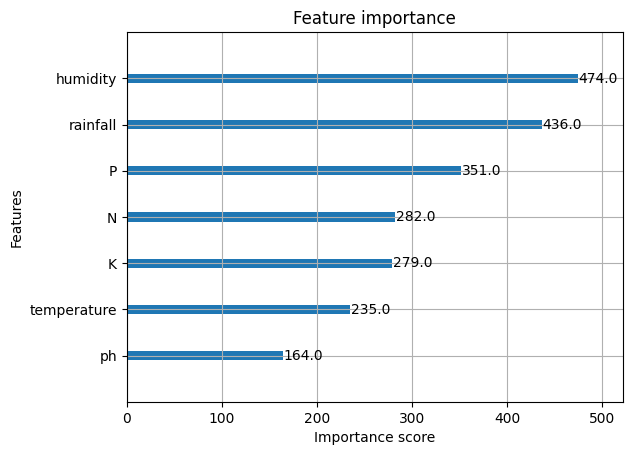

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_search_xgb = GridSearchCV(estimator=XGBClassifier(random_state=42),
                               param_grid=param_grid_xgb,
                               cv=5,
                               scoring='accuracy',
                               n_jobs=-1,
                               verbose=1)

print("Performing GridSearchCV for XGBoost...")
grid_search_xgb.fit(x_train, y_train_encoded)

print("\nXGBoost Best Parameters:", grid_search_xgb.best_params_)
print("XGBoost Best Score:", grid_search_xgb.best_score_)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=param_grid_rf,
                              cv=5,
                              scoring='accuracy',
                              n_jobs=-1,
                              verbose=1)

print("\nPerforming GridSearchCV for Random Forest...")
grid_search_rf.fit(x_train, y_train_encoded)

print("\nRandom Forest Best Parameters:", grid_search_rf.best_params_)
print("Random Forest Best Score:", grid_search_rf.best_score_)

Performing GridSearchCV for XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

XGBoost Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
XGBoost Best Score: 0.990340909090909

Performing GridSearchCV for Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Random Forest Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Best Score: 0.9948863636363636


In [ ]:
best_xgb = grid_search_xgb.best_estimator_
best_rf  = grid_search_rf.best_estimator_
from sklearn.metrics import accuracy_score

xgb_pred = best_xgb.predict(x_test)
rf_pred  = best_rf.predict(x_test)

print("XGB Test Accuracy:", accuracy_score(y_test_encoded, xgb_pred))
print("RF Test Accuracy :", accuracy_score(y_test_encoded, rf_pred))

XGB Test Accuracy: 0.9886363636363636
RF Test Accuracy : 0.9931818181818182


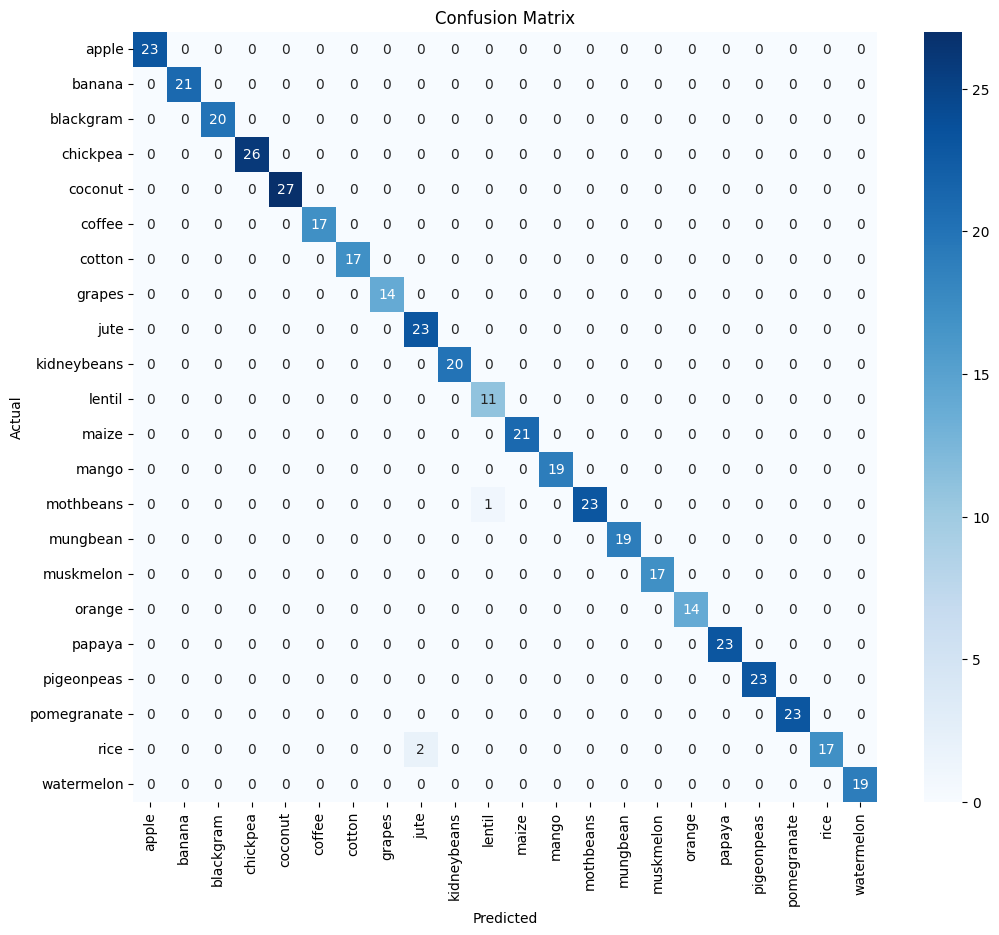

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# The error occurs because df['label'] contains string labels,
# while y_test_encoded and y_pred_encoded contain integer labels.
# The confusion_matrix function expects consistent label types.
# Removing the 'labels' argument allows it to infer integer labels.
cm = confusion_matrix(y_test_encoded, rf_pred)

# To make the heatmap readable with original crop names,
# use le.classes_ for xticklabels and yticklabels in seaborn.heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size for better display of many labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_encoded,y_pred_encoded))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.92      0.96      0.94        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
          17       1.00    

In [ ]:
import joblib
joblib.dump(grid_search_rf.best_estimator_,"crop_recomen.pkl")

['crop_recomen.pkl']

In [ ]:
from google.colab import files
files.download('crop_recomen.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>